<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Stability007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 500/500 [00:00<00:00, 819.43it/s]


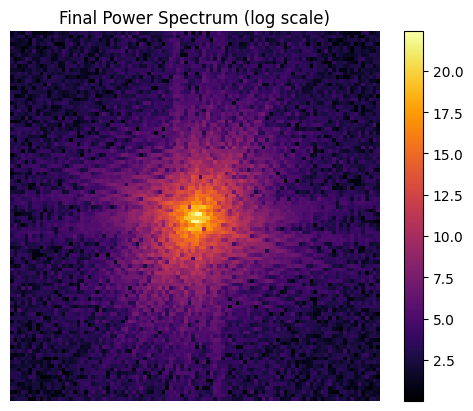

StabilitySweep001 (N=100) → λ_dom ≈ 100.00


In [1]:
# StabilitySweep001 — Act XXXVIII: The Emergent Harmonic
# Pure emergence test at N=100 (no fixed scale, no structural bias)

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from tqdm import tqdm

# --- Parameters ---
alpha, beta, gamma, delta = 0.1, 0.01, 0.2, 0.02
T_max = 500
L = 100
seed = 42

# --- Initialize Field ---
np.random.seed(seed)
Phi = np.random.randn(L, L)

# --- Laplacian Function ---
def laplacian(Phi):
    return (
        np.roll(Phi, 1, axis=0) + np.roll(Phi, -1, axis=0) +
        np.roll(Phi, 1, axis=1) + np.roll(Phi, -1, axis=1) -
        4 * Phi
    )

# --- Lambda Extraction ---
def extract_lambda_dom(Phi):
    spectrum = np.abs(fftshift(fft2(Phi)))**2
    center = np.array(spectrum.shape) // 2
    spectrum[center[0], center[1]] = 0
    peak_idx = np.unravel_index(np.argmax(spectrum), spectrum.shape)
    kx = peak_idx[1] - center[1]
    ky = peak_idx[0] - center[0]
    k_dom = np.sqrt(kx**2 + ky**2) / L
    return 1 / k_dom if k_dom != 0 else np.inf

# --- Evolution Loop ---
for t in tqdm(range(T_max)):
    Phi += alpha * laplacian(Phi) - beta * Phi + gamma * np.tanh(Phi) + delta * np.random.randn(L, L)

# --- Final Spectrum and Output ---
spectrum = np.abs(fftshift(fft2(Phi)))**2
lambda_dom = extract_lambda_dom(Phi)

# --- Visualization ---
plt.imshow(np.log1p(spectrum), cmap='inferno')
plt.title('Final Power Spectrum (log scale)')
plt.colorbar()
plt.axis('off')
plt.show()

# --- Result ---
print(f"StabilitySweep001 (N=100) → λ_dom ≈ {lambda_dom:.2f}")
